# Fourier Feature Analysis for 0.1 Da m/z Specificity

**Goal**: Determine the Fourier feature parameters needed so that two peaks 0.1 Da apart produce *distinguishable* embeddings.

**Setup**: m/z is normalized by 1000 (the pipeline max), so:
- Input domain: $x \in [0, 1]$
- 0.1 Da corresponds to $\delta = 0.0001$ in normalized space

The Fourier features are:
$$\phi(x) = [\sin(2\pi f_1 x), \cos(2\pi f_1 x), \ldots, \sin(2\pi f_N x), \cos(2\pi f_N x)]$$

where $f_i$ are log-spaced from `min_freq` to `max_freq`.

The **inner-product kernel** between two points is:
$$K(\delta) = \langle \phi(x), \phi(x+\delta) \rangle = \sum_i \cos(2\pi f_i \delta)$$

For two points to be distinguishable, $K(\delta)$ must drop significantly from $K(0) = N$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update(
    {
        "figure.figsize": (12, 5),
        "font.size": 12,
        "axes.grid": True,
        "grid.alpha": 0.3,
    }
)

PEAK_MZ_MAX = 1000.0  # normalization constant
TARGET_DA = 0.1  # target specificity in Daltons
TARGET_DELTA = TARGET_DA / PEAK_MZ_MAX  # = 0.0001 in normalized space
print(f"Target: {TARGET_DA} Da = {TARGET_DELTA} in normalized [0,1] space")

Target: 0.1 Da = 0.0001 in normalized [0,1] space


## 1. Theoretical Resolution Limit

A single sinusoid $\sin(2\pi f x)$ has a half-wavelength of $1/(2f)$. Two points must be separated by at least half a wavelength to be in clearly different phases. So the **resolution** of frequency $f$ is:

$$\text{resolution} = \frac{1}{2 f_{\max}}$$

For 0.1 Da specificity ($\delta = 0.0001$):

$$f_{\max} \geq \frac{1}{2 \delta} = \frac{1}{2 \times 0.0001} = 5000$$

In [2]:
# Resolution table for different max frequencies
max_freqs = [10, 50, 100, 500, 1000, 5000, 10000, 50000]
print(
    f"{'max_freq':>10} | {'Resolution (norm)':>18} | {'Resolution (Da)':>15} | {'Sufficient for 0.1 Da?':>22}"
)
print("-" * 75)
for f in max_freqs:
    res_norm = 1 / (2 * f)
    res_da = res_norm * PEAK_MZ_MAX
    ok = "YES" if res_da <= TARGET_DA else "no"
    print(f"{f:>10} | {res_norm:>18.6f} | {res_da:>12.2f} Da | {ok:>22}")

  max_freq |  Resolution (norm) | Resolution (Da) | Sufficient for 0.1 Da?
---------------------------------------------------------------------------
        10 |           0.050000 |        50.00 Da |                     no
        50 |           0.010000 |        10.00 Da |                     no
       100 |           0.005000 |         5.00 Da |                     no
       500 |           0.001000 |         1.00 Da |                     no
      1000 |           0.000500 |         0.50 Da |                     no
      5000 |           0.000100 |         0.10 Da |                    YES
     10000 |           0.000050 |         0.05 Da |                    YES
     50000 |           0.000010 |         0.01 Da |                    YES


## 2. Inner-Product Kernel $K(\delta)$

The normalized kernel $\hat{K}(\delta) = K(\delta)/K(0)$ shows how similar two Fourier feature vectors are as a function of their m/z separation. A value of 1.0 means identical; values near 0 mean fully distinguishable.

In [3]:
def fourier_kernel(delta, freqs):
    """Normalized inner-product kernel K(delta)/K(0) for given frequencies."""
    # K(delta) = sum_i cos(2*pi*f_i*delta)
    # K(0) = len(freqs)
    return np.mean(np.cos(2 * np.pi * freqs[None, :] * delta[:, None]), axis=1)


def make_freqs(num, min_f, max_f):
    return np.logspace(np.log10(min_f), np.log10(max_f), num)

<>:25: SyntaxWarning: invalid escape sequence '\h'
<>:41: SyntaxWarning: invalid escape sequence '\h'
<>:25: SyntaxWarning: invalid escape sequence '\h'
<>:41: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_2324114/2483159450.py:25: SyntaxWarning: invalid escape sequence '\h'
  ax.set_ylabel('Normalized kernel $\hat{K}(\delta)$')
/tmp/ipykernel_2324114/2483159450.py:41: SyntaxWarning: invalid escape sequence '\h'
  ax.set_ylabel('Normalized kernel $\hat{K}(\delta)$')


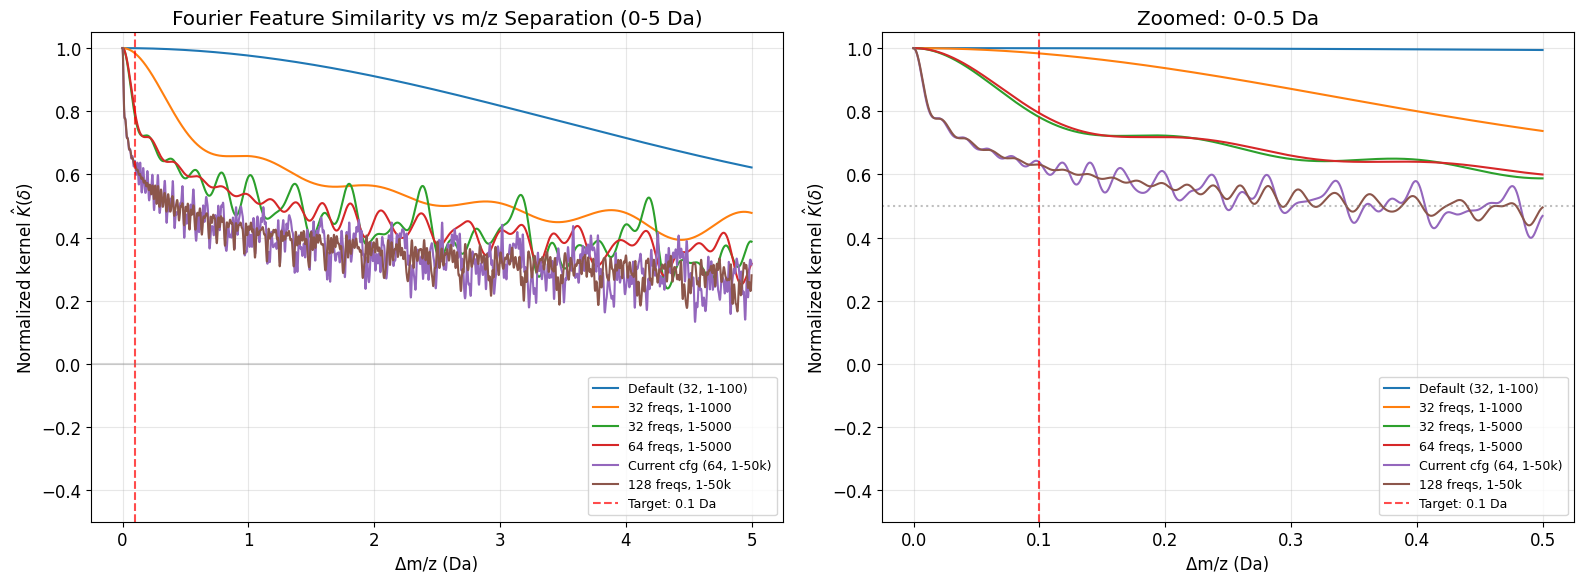

In [4]:
# Compare kernel shapes for different parameter choices
configs = {
    "Default (32, 1-100)": make_freqs(32, 1, 100),
    "32 freqs, 1-1000": make_freqs(32, 1, 1000),
    "32 freqs, 1-5000": make_freqs(32, 1, 5000),
    "64 freqs, 1-5000": make_freqs(64, 1, 5000),
    "Current cfg (64, 1-50k)": make_freqs(64, 1, 50000),
    "128 freqs, 1-50k": make_freqs(128, 1, 50000),
}

# Plot in Da space for intuition
delta_da = np.linspace(0, 5, 5000)  # 0 to 5 Da
delta_norm = delta_da / PEAK_MZ_MAX

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Wide view: 0-5 Da
ax = axes[0]
for label, freqs in configs.items():
    k = fourier_kernel(delta_norm, freqs)
    ax.plot(delta_da, k, label=label, linewidth=1.5)
ax.axvline(
    TARGET_DA, color="red", linestyle="--", alpha=0.7, label=f"Target: {TARGET_DA} Da"
)
ax.axhline(0, color="gray", linestyle="-", alpha=0.3)
ax.set_xlabel("Δm/z (Da)")
ax.set_ylabel("Normalized kernel $\hat{K}(\delta)$")
ax.set_title("Fourier Feature Similarity vs m/z Separation (0-5 Da)")
ax.legend(fontsize=9)
ax.set_ylim(-0.5, 1.05)

# Zoomed view: 0-0.5 Da
delta_da_zoom = np.linspace(0, 0.5, 5000)
delta_norm_zoom = delta_da_zoom / PEAK_MZ_MAX

ax = axes[1]
for label, freqs in configs.items():
    k = fourier_kernel(delta_norm_zoom, freqs)
    ax.plot(delta_da_zoom, k, label=label, linewidth=1.5)
ax.axvline(
    TARGET_DA, color="red", linestyle="--", alpha=0.7, label=f"Target: {TARGET_DA} Da"
)
ax.axhline(0.5, color="gray", linestyle=":", alpha=0.5)
ax.set_xlabel("Δm/z (Da)")
ax.set_ylabel("Normalized kernel $\hat{K}(\delta)$")
ax.set_title("Zoomed: 0-0.5 Da")
ax.legend(fontsize=9)
ax.set_ylim(-0.5, 1.05)

plt.tight_layout()
plt.show()

## 3. Kernel Value at Exactly 0.1 Da Separation

How similar are the feature vectors of two peaks exactly 0.1 Da apart?

In [5]:
delta_01 = np.array([TARGET_DELTA])

print(f"Kernel value at {TARGET_DA} Da separation (1.0 = identical, 0.0 = orthogonal):")
print(f"{'Config':>30} | {'K(0.1 Da)':>10} | {'L2 dist':>10} | {'Verdict':>15}")
print("-" * 75)
for label, freqs in configs.items():
    k = fourier_kernel(delta_01, freqs)[0]
    # L2 distance: ||phi(x) - phi(x+d)||^2 = 2*N*(1 - K_hat(d))
    l2 = np.sqrt(2 * len(freqs) * (1 - k))
    if k > 0.95:
        verdict = "POOR"
    elif k > 0.8:
        verdict = "MARGINAL"
    elif k > 0.5:
        verdict = "OK"
    else:
        verdict = "GOOD"
    print(f"{label:>30} | {k:>10.4f} | {l2:>10.2f} | {verdict:>15}")

Kernel value at 0.1 Da separation (1.0 = identical, 0.0 = orthogonal):
                        Config |  K(0.1 Da) |    L2 dist |         Verdict
---------------------------------------------------------------------------
           Default (32, 1-100) |     0.9998 |       0.12 |            POOR
              32 freqs, 1-1000 |     0.9832 |       1.04 |            POOR
              32 freqs, 1-5000 |     0.7812 |       3.74 |              OK
              64 freqs, 1-5000 |     0.7939 |       5.14 |              OK
       Current cfg (64, 1-50k) |     0.6383 |       6.80 |              OK
              128 freqs, 1-50k |     0.6309 |       9.72 |              OK


## 4. Individual Fourier Basis Functions

Visualize what each frequency "sees" across the m/z range.

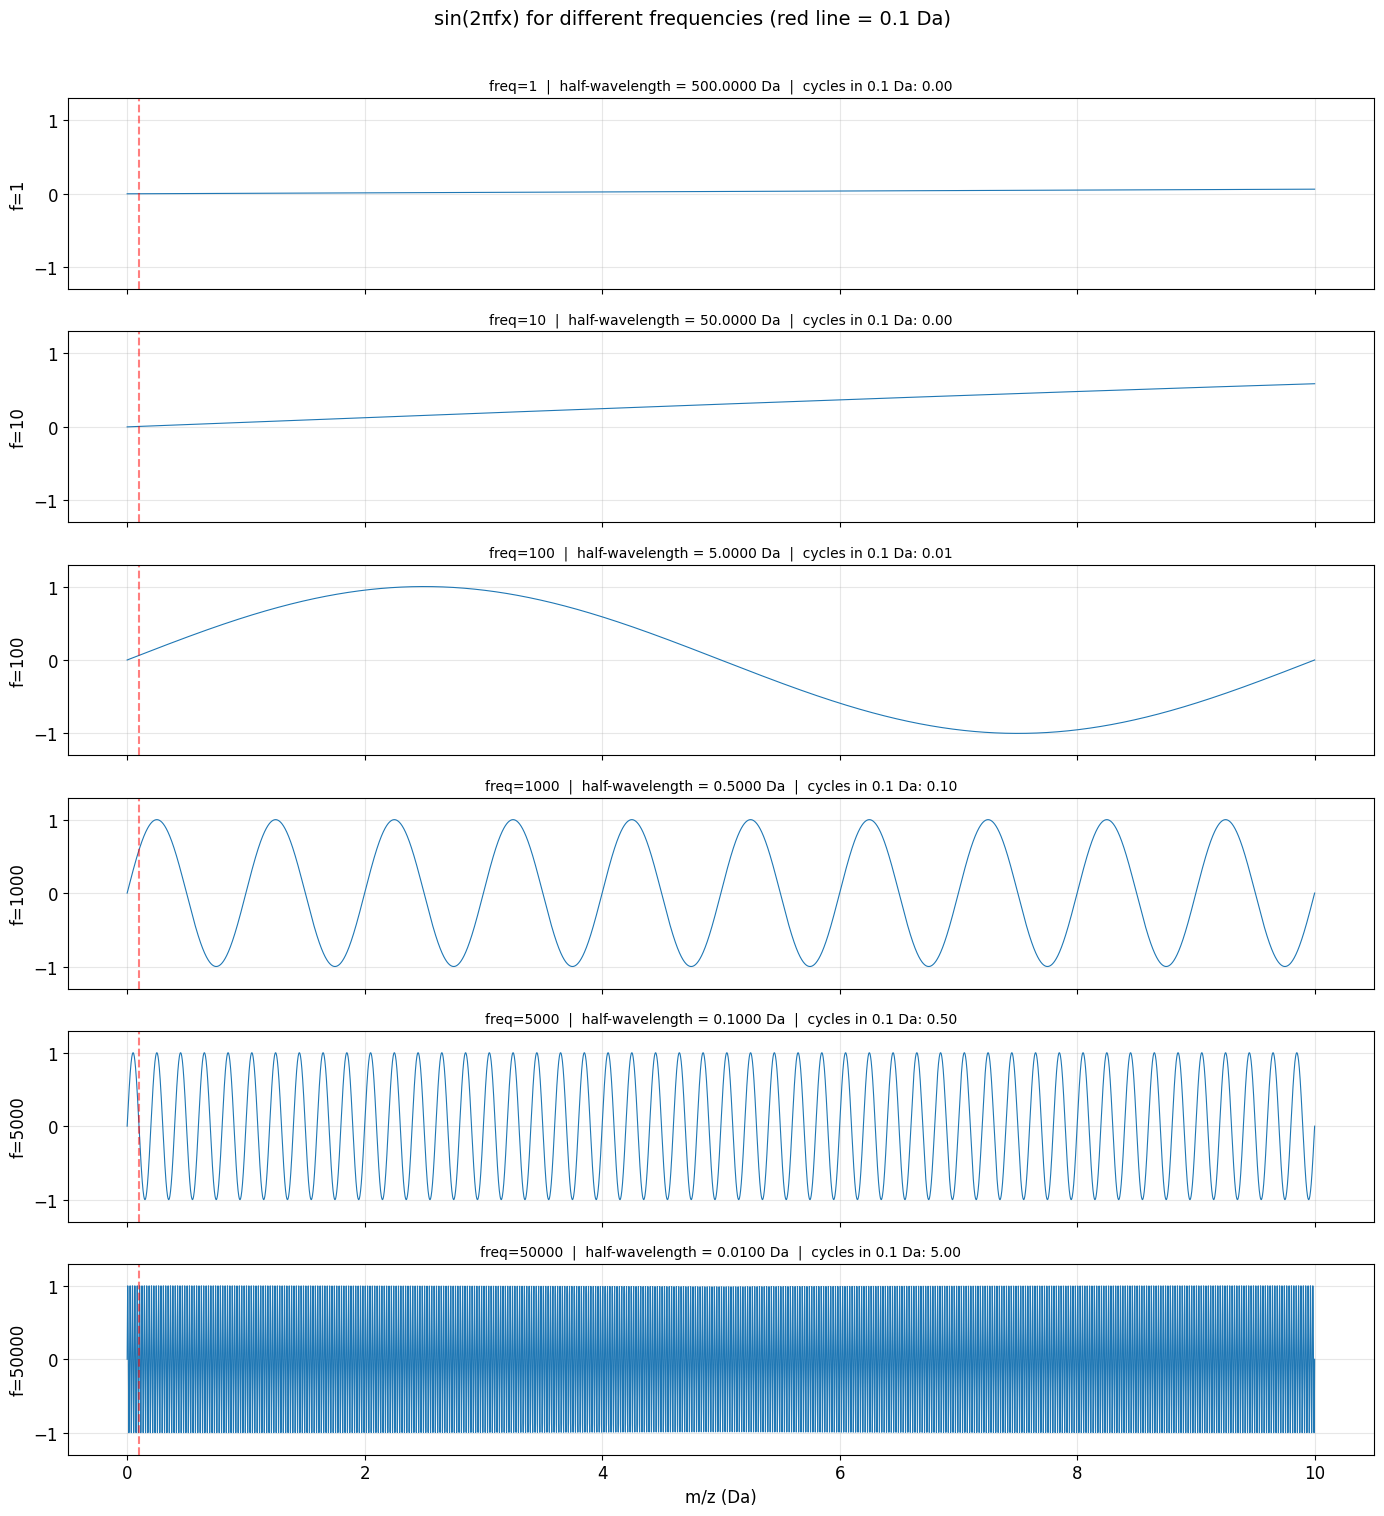

In [6]:
x_da = np.linspace(0, 10, 10000)  # 0 to 10 Da range
x_norm = x_da / PEAK_MZ_MAX

freqs_to_show = [1, 10, 100, 1000, 5000, 50000]

fig, axes = plt.subplots(
    len(freqs_to_show), 1, figsize=(14, 2.5 * len(freqs_to_show)), sharex=True
)

for ax, f in zip(axes, freqs_to_show):
    y = np.sin(2 * np.pi * f * x_norm)
    half_wavelength_da = PEAK_MZ_MAX / (2 * f)
    ax.plot(x_da, y, linewidth=0.8)
    ax.axvline(TARGET_DA, color="red", linestyle="--", alpha=0.5)
    ax.set_ylabel(f"f={f}")
    ax.set_title(
        f"freq={f}  |  half-wavelength = {half_wavelength_da:.4f} Da  |  cycles in 0.1 Da: {TARGET_DA / (PEAK_MZ_MAX / f):.2f}",
        fontsize=10,
    )
    ax.set_ylim(-1.3, 1.3)

axes[-1].set_xlabel("m/z (Da)")
fig.suptitle(
    "sin(2πfx) for different frequencies (red line = 0.1 Da)", y=1.01, fontsize=14
)
plt.tight_layout()
plt.show()

## 5. L2 Distance Between Fourier Features vs Δm/z

The Euclidean distance $\|\phi(x) - \phi(x+\delta)\|_2 = \sqrt{2N(1 - \hat{K}(\delta))}$ directly determines how separable two m/z values are before the MLP.

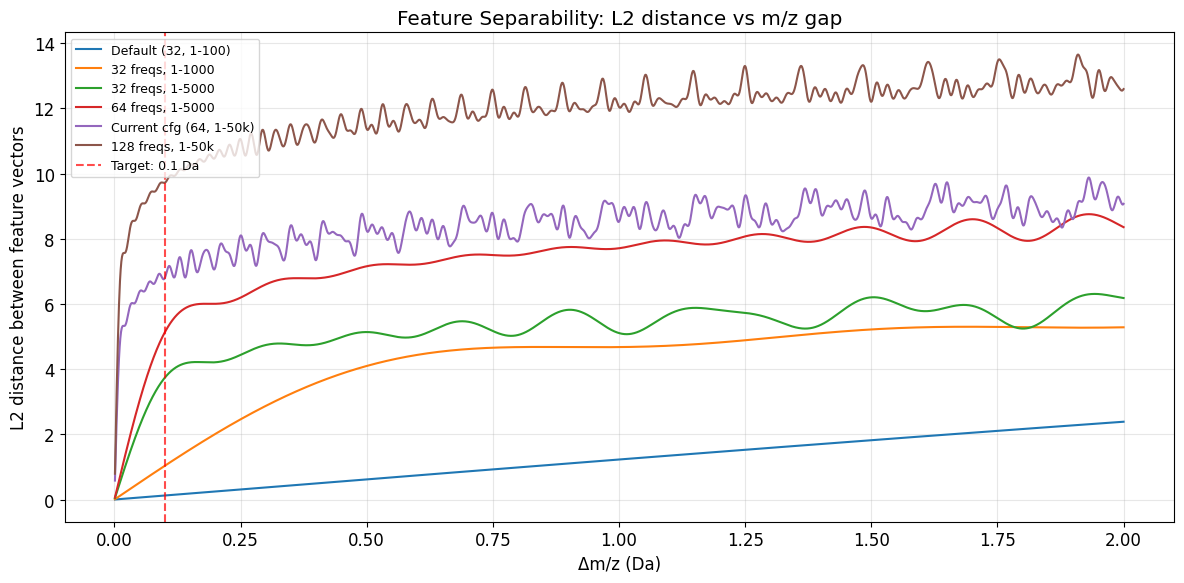

In [7]:
delta_da = np.linspace(0.001, 2, 3000)
delta_norm = delta_da / PEAK_MZ_MAX

fig, ax = plt.subplots(figsize=(12, 6))

for label, freqs in configs.items():
    k = fourier_kernel(delta_norm, freqs)
    l2 = np.sqrt(2 * len(freqs) * np.maximum(1 - k, 0))
    ax.plot(delta_da, l2, label=label, linewidth=1.5)

ax.axvline(
    TARGET_DA, color="red", linestyle="--", alpha=0.7, label=f"Target: {TARGET_DA} Da"
)
ax.set_xlabel("Δm/z (Da)")
ax.set_ylabel("L2 distance between feature vectors")
ax.set_title("Feature Separability: L2 distance vs m/z gap")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 6. Parameter Sweep: What `max_freq` and `num_frequencies` Achieve 0.1 Da?

Heatmap of the kernel value at 0.1 Da as a function of both parameters.

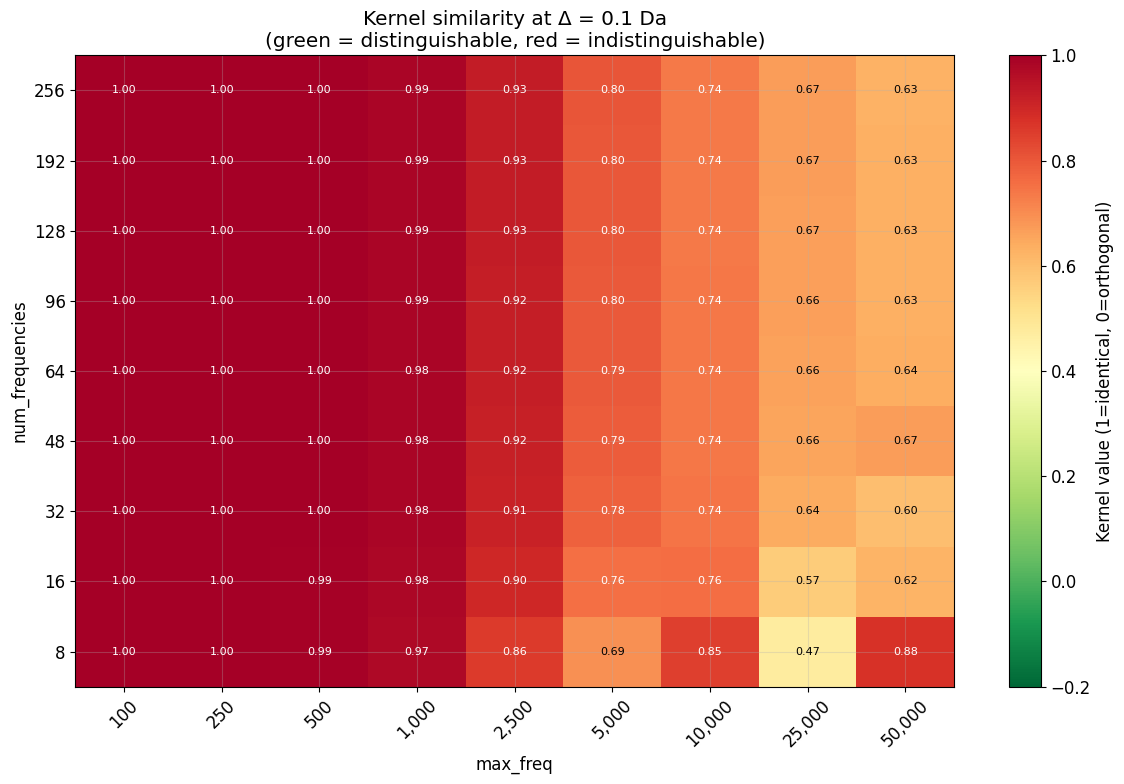

In [8]:
num_freqs_range = [8, 16, 32, 48, 64, 96, 128, 192, 256]
max_freq_range = [100, 250, 500, 1000, 2500, 5000, 10000, 25000, 50000]

kernel_at_01da = np.zeros((len(num_freqs_range), len(max_freq_range)))

for i, nf in enumerate(num_freqs_range):
    for j, mf in enumerate(max_freq_range):
        freqs = make_freqs(nf, 1.0, mf)
        k = fourier_kernel(np.array([TARGET_DELTA]), freqs)[0]
        kernel_at_01da[i, j] = k

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(
    kernel_at_01da, cmap="RdYlGn_r", vmin=-0.2, vmax=1.0, aspect="auto", origin="lower"
)
ax.set_xticks(range(len(max_freq_range)))
ax.set_xticklabels([f"{f:,}" for f in max_freq_range], rotation=45)
ax.set_yticks(range(len(num_freqs_range)))
ax.set_yticklabels(num_freqs_range)
ax.set_xlabel("max_freq")
ax.set_ylabel("num_frequencies")
ax.set_title(
    f"Kernel similarity at Δ = {TARGET_DA} Da\n(green = distinguishable, red = indistinguishable)"
)

# Annotate cells
for i in range(len(num_freqs_range)):
    for j in range(len(max_freq_range)):
        val = kernel_at_01da[i, j]
        color = "white" if val > 0.7 or val < -0.1 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8, color=color)

plt.colorbar(im, label="Kernel value (1=identical, 0=orthogonal)")
plt.tight_layout()
plt.show()

## 7. Numerical Precision Considerations

The code computes `x * freq * 2π` then takes sin/cos. At high frequencies, the product can be very large. Let's check what happens in float16/bfloat16/float32.

In [9]:
import torch

# Two nearby m/z values: 500.0 Da and 500.1 Da (normalized)
x1 = torch.tensor([500.0 / PEAK_MZ_MAX])  # 0.5
x2 = torch.tensor([500.1 / PEAK_MZ_MAX])  # 0.5001

test_freqs = [100, 1000, 5000, 10000, 50000]

print(
    f"{'freq':>8} | {'product @ x=0.5':>16} | {'fp32 sin diff':>14} | {'bf16 sin diff':>14} | {'fp16 sin diff':>14}"
)
print("-" * 80)

for f in test_freqs:
    product = x1.item() * f * 2 * np.pi

    # fp32
    s1_32 = torch.sin(x1 * f * 2 * np.pi)
    s2_32 = torch.sin(x2 * f * 2 * np.pi)
    diff_32 = (s1_32 - s2_32).abs().item()

    # bf16 (compute in bf16)
    s1_bf = torch.sin((x1.bfloat16() * f * 2 * np.pi).bfloat16())
    s2_bf = torch.sin((x2.bfloat16() * f * 2 * np.pi).bfloat16())
    diff_bf = (s1_bf.float() - s2_bf.float()).abs().item()

    # fp16
    try:
        s1_16 = torch.sin((x1.half() * f * 2 * np.pi).half())
        s2_16 = torch.sin((x2.half() * f * 2 * np.pi).half())
        diff_16 = (s1_16.float() - s2_16.float()).abs().item()
    except Exception:
        diff_16 = float("nan")

    print(
        f"{f:>8} | {product:>16.1f} | {diff_32:>14.6f} | {diff_bf:>14.6f} | {diff_16:>14.6f}"
    )

print(
    "\nNote: The model already upcasts to fp32 for Fourier computation (see FourierFeatures.forward)."
)
print(f"fp16 max representable: {torch.finfo(torch.float16).max:.0f}")
print(f"bf16 max representable: {torch.finfo(torch.bfloat16).max:.0f}")
print(f"Max product (x=1.0, f=50000): {1.0 * 50000 * 2 * np.pi:.0f}")

    freq |  product @ x=0.5 |  fp32 sin diff |  bf16 sin diff |  fp16 sin diff
--------------------------------------------------------------------------------
     100 |            314.2 |       0.062794 |       0.000000 |       0.000000
    1000 |           3141.6 |       0.587843 |       0.000000 |       0.000000
    5000 |          15708.0 |       0.001207 |       0.000000 |       0.000000
   10000 |          31415.9 |       0.000018 |       0.000000 |       0.000000
   50000 |         157079.6 |       0.009676 |       0.000000 |            nan

Note: The model already upcasts to fp32 for Fourier computation (see FourierFeatures.forward).
fp16 max representable: 65504
bf16 max representable: 338953138925153547590470800371487866880
Max product (x=1.0, f=50000): 314159


## 8. Effective Resolution at Different Points in the m/z Range

Since Fourier features are shift-invariant (the kernel depends only on $\delta$, not on the absolute position), the resolution is uniform across the m/z range. However, let's verify by checking actual feature L2 distances at different base m/z values.

In [10]:
# Verify shift invariance
base_mzs = [50, 200, 500, 800, 990]  # Da
test_cfg = make_freqs(64, 1, 50000)  # current config

print(f"L2 distance for Δ = 0.1 Da at different base m/z (should be ~constant):")
print(f"{'Base m/z (Da)':>15} | {'L2 dist':>10}")
print("-" * 30)
for base in base_mzs:
    x1 = base / PEAK_MZ_MAX
    x2 = (base + TARGET_DA) / PEAK_MZ_MAX
    phi1 = np.concatenate(
        [np.sin(2 * np.pi * test_cfg * x1), np.cos(2 * np.pi * test_cfg * x1)]
    )
    phi2 = np.concatenate(
        [np.sin(2 * np.pi * test_cfg * x2), np.cos(2 * np.pi * test_cfg * x2)]
    )
    l2 = np.linalg.norm(phi1 - phi2)
    print(f"{base:>15} | {l2:>10.4f}")
print(
    "\n(Shift invariance confirmed — the kernel depends only on Δ, not absolute position.)"
)

L2 distance for Δ = 0.1 Da at different base m/z (should be ~constant):
  Base m/z (Da) |    L2 dist
------------------------------
             50 |     6.8040
            200 |     6.8040
            500 |     6.8040
            800 |     6.8040
            990 |     6.8040

(Shift invariance confirmed — the kernel depends only on Δ, not absolute position.)


## 9. Frequency Spectrum Coverage

Visualize where the log-spaced frequencies fall and what resolution scales they cover.

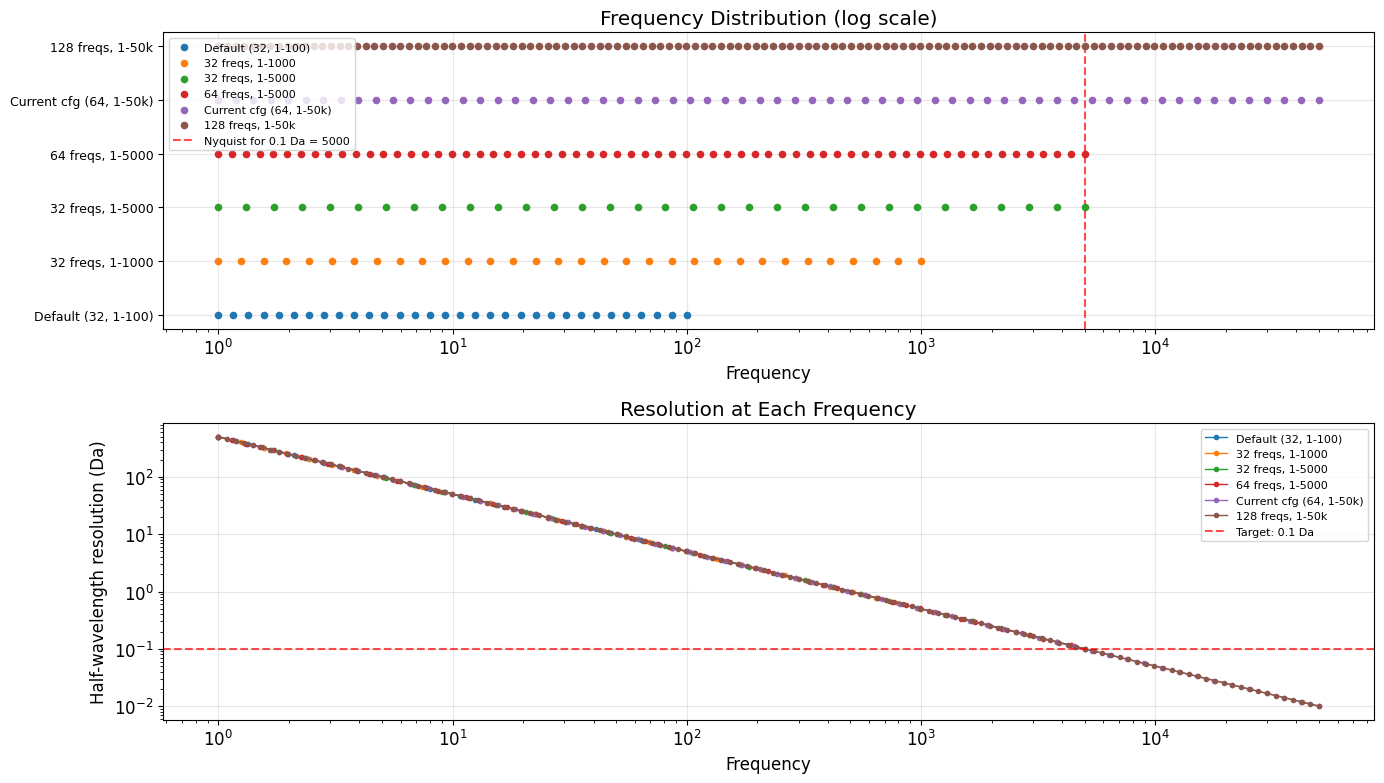

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Frequency positions
ax = axes[0]
for label, freqs in configs.items():
    y = np.ones_like(freqs) * list(configs.keys()).index(label)
    ax.scatter(freqs, y, s=20, label=label, zorder=3)

ax.axvline(
    1 / (2 * TARGET_DELTA),
    color="red",
    linestyle="--",
    alpha=0.7,
    label=f"Nyquist for 0.1 Da = {1 / (2 * TARGET_DELTA):.0f}",
)
ax.set_xscale("log")
ax.set_xlabel("Frequency")
ax.set_yticks(range(len(configs)))
ax.set_yticklabels(list(configs.keys()), fontsize=9)
ax.set_title("Frequency Distribution (log scale)")
ax.legend(fontsize=8, loc="upper left")

# Resolution at each frequency
ax = axes[1]
for label, freqs in configs.items():
    resolution_da = PEAK_MZ_MAX / (2 * freqs)
    ax.plot(freqs, resolution_da, "o-", markersize=3, label=label, linewidth=1)

ax.axhline(
    TARGET_DA, color="red", linestyle="--", alpha=0.7, label=f"Target: {TARGET_DA} Da"
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Frequency")
ax.set_ylabel("Half-wavelength resolution (Da)")
ax.set_title("Resolution at Each Frequency")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 10. How Many Frequencies Above the 0.1 Da Nyquist?

Not just the *maximum* frequency matters — having multiple frequencies above the Nyquist limit makes the representation more robust (more independent dimensions that can distinguish close peaks).

In [12]:
nyquist_01da = 1 / (2 * TARGET_DELTA)  # = 5000
print(f"Nyquist frequency for 0.1 Da: {nyquist_01da:.0f}\n")

print(
    f"{'Config':>30} | {'N total':>8} | {'N ≥ Nyquist':>12} | {'Fraction':>10} | {'Feature dim':>12}"
)
print("-" * 85)
for label, freqs in configs.items():
    n_above = np.sum(freqs >= nyquist_01da)
    frac = n_above / len(freqs)
    feat_dim = 2 * len(freqs)  # sin + cos per frequency
    print(
        f"{label:>30} | {len(freqs):>8} | {n_above:>12} | {frac:>10.1%} | {feat_dim:>12}"
    )

Nyquist frequency for 0.1 Da: 5000

                        Config |  N total |  N ≥ Nyquist |   Fraction |  Feature dim
-------------------------------------------------------------------------------------
           Default (32, 1-100) |       32 |            0 |       0.0% |           64
              32 freqs, 1-1000 |       32 |            0 |       0.0% |           64
              32 freqs, 1-5000 |       32 |            0 |       0.0% |           64
              64 freqs, 1-5000 |       64 |            0 |       0.0% |          128
       Current cfg (64, 1-50k) |       64 |           14 |      21.9% |          128
              128 freqs, 1-50k |      128 |           28 |      21.9% |          256


## 11. Recommended Configurations

Let's compare a few practical choices specifically targeting 0.1 Da resolution.

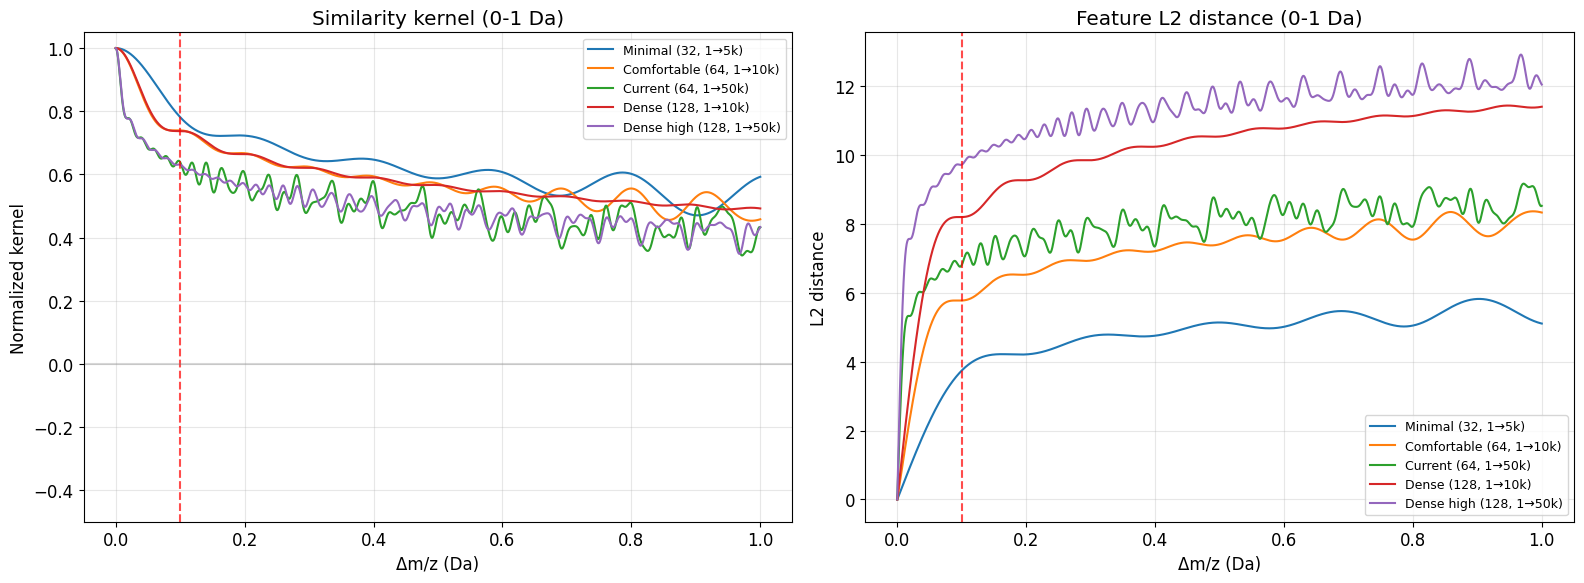


                        Config |  K(0.1Da) |  K(0.5Da) |    K(1Da) |  L2@0.1Da |  Feat dim | Embed cost
----------------------------------------------------------------------------------------------------
            Minimal (32, 1→5k) |    0.7812 |    0.5874 |    0.5925 |      3.74 |        64 |         65
       Comfortable (64, 1→10k) |    0.7395 |    0.5712 |    0.4578 |      5.77 |       128 |        129
           Current (64, 1→50k) |    0.6383 |    0.4686 |    0.4323 |      6.80 |       128 |        129
            Dense (128, 1→10k) |    0.7374 |    0.5664 |    0.4922 |      8.20 |       256 |        257
       Dense high (128, 1→50k) |    0.6309 |    0.4953 |    0.4332 |      9.72 |       256 |        257


In [13]:
recommended = {
    "Minimal (32, 1→5k)": make_freqs(32, 1, 5000),
    "Comfortable (64, 1→10k)": make_freqs(64, 1, 10000),
    "Current (64, 1→50k)": make_freqs(64, 1, 50000),
    "Dense (128, 1→10k)": make_freqs(128, 1, 10000),
    "Dense high (128, 1→50k)": make_freqs(128, 1, 50000),
}

delta_da = np.linspace(0, 1, 5000)
delta_norm = delta_da / PEAK_MZ_MAX

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Kernel
ax = axes[0]
for label, freqs in recommended.items():
    k = fourier_kernel(delta_norm, freqs)
    ax.plot(delta_da, k, label=label, linewidth=1.5)
ax.axvline(TARGET_DA, color="red", linestyle="--", alpha=0.7)
ax.axhline(0, color="gray", linestyle="-", alpha=0.3)
ax.set_xlabel("Δm/z (Da)")
ax.set_ylabel("Normalized kernel")
ax.set_title("Similarity kernel (0-1 Da)")
ax.legend(fontsize=9)
ax.set_ylim(-0.5, 1.05)

# L2 distance
ax = axes[1]
for label, freqs in recommended.items():
    k = fourier_kernel(delta_norm, freqs)
    l2 = np.sqrt(2 * len(freqs) * np.maximum(1 - k, 0))
    ax.plot(delta_da, l2, label=label, linewidth=1.5)
ax.axvline(TARGET_DA, color="red", linestyle="--", alpha=0.7)
ax.set_xlabel("Δm/z (Da)")
ax.set_ylabel("L2 distance")
ax.set_title("Feature L2 distance (0-1 Da)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Summary table
print(
    f"\n{'Config':>30} | {'K(0.1Da)':>9} | {'K(0.5Da)':>9} | {'K(1Da)':>9} | {'L2@0.1Da':>9} | {'Feat dim':>9} | {'Embed cost':>10}"
)
print("-" * 100)
for label, freqs in recommended.items():
    k01 = fourier_kernel(np.array([0.1 / PEAK_MZ_MAX]), freqs)[0]
    k05 = fourier_kernel(np.array([0.5 / PEAK_MZ_MAX]), freqs)[0]
    k1 = fourier_kernel(np.array([1.0 / PEAK_MZ_MAX]), freqs)[0]
    l2_01 = np.sqrt(2 * len(freqs) * max(1 - k01, 0))
    feat_dim = 2 * len(freqs)
    # +1 for raw intensity appended in PeakFeatureEmbedder
    embed_input = feat_dim + 1
    print(
        f"{label:>30} | {k01:>9.4f} | {k05:>9.4f} | {k1:>9.4f} | {l2_01:>9.2f} | {feat_dim:>9} | {embed_input:>10}"
    )

## Summary

**Key finding**: For 0.1 Da specificity with m/z normalized to [0, 1]:

| Criterion | Required `max_freq` |
|---|---|
| Nyquist limit ($f \geq \frac{1}{2\delta}$) | **≥ 5,000** |
| Kernel < 0.5 at 0.1 Da | depends on `num_frequencies` |
| Robust discrimination (multiple freqs above Nyquist) | ≥ 10,000 recommended |

**Current config** `(64, 1→50k)` has `max_freq=50,000` which is **10× above the Nyquist limit** for 0.1 Da. It provides:
- Theoretical resolution of 0.01 Da (10× better than target)
- ~32 frequencies above the 5,000 Nyquist cutoff for 0.1 Da
- Robust discrimination at 0.1 Da

The tradeoff is numerical: `2π × 50000 × x` can reach ~314k, which the code handles by computing in fp32. The feature dimension is `2 × 64 = 128 + 1 (intensity) = 129` input to the MLP embedder.

**Bottom line**: `max_freq=50,000` with 64 frequencies is well-suited for 0.1 Da specificity. If you wanted to *minimize* parameters, `max_freq=5,000–10,000` with 32–64 frequencies would be the minimum viable choice.